# Análisis de Riesgo Crediticio

Presentado por:
- Jhofred Jahat Camacho Gomez (jhcamacho@unal.edu.co).
- Sebastián Pabón Nuñez (sepabonn@unal.edu.co).

## Introducción

Usando https://www.kaggle.com/datasets/ranadeep/credit-risk-dataset/data se busca predecir si un cliente es potencial deudor, basado en la variable objetivo "loan_status"

## Análisis Exploratiorio

Primero, realizamos lectura del dataset

In [1]:
import pandas as pd

df = pd.read_csv('../data/loan/loan.csv', low_memory=False)

print("First 5 records:")
display(df.head())

First 5 records:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


También, existe un excel con metadatos y definiciones del dataset que será de ayuda

Exploremos algunas propiedades generales del dataset

In [2]:
# número de observaciones y features
df.shape

(887379, 74)

In [3]:
df[df.duplicated()]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m


Como se puede observar, no hay filas duplicadas.

In [4]:
# missing values por feature
# Miramos las columnas que tienen mas de 10% de valores nulos
high_missing_values = df.isna().sum().sort_values()[df.isna().sum().sort_values() > df.shape[0] * 0.1]

print("Total de columnas con más de 10% de valores faltantes: ", high_missing_values.shape[0])

high_missing_values


Total de columnas con más de 10% de valores faltantes:  22


next_pymnt_d                   252971
mths_since_last_delinq         454312
mths_since_last_major_derog    665676
mths_since_last_record         750326
desc                           761353
open_il_6m                     866007
open_il_24m                    866007
open_il_12m                    866007
open_rv_12m                    866007
open_rv_24m                    866007
total_bal_il                   866007
open_acc_6m                    866007
inq_last_12m                   866007
max_bal_bc                     866007
inq_fi                         866007
total_cu_tl                    866007
all_util                       866007
mths_since_rcnt_il             866569
il_util                        868762
annual_inc_joint               886868
verification_status_joint      886868
dti_joint                      886870
dtype: int64

Como se puede observar, el dataset contiene columnas con gran cantidad de nulos, superando por mucho el 10%, por lo que es díficil hacer un modelo que use dichas columnas.

## Data Cleaning

In [5]:
df_cleaned = df.copy()

### Conversión de variable objetivo

Primero, convertamos nuestra variable objetivo loan_status teniendo en cuenta el siguiente criterio:

- "Current": Clientes que están al día. Codificación: NA. Justificación: No hay certeza sobre su comportamiento final de pago.
- "Fully paid": Créditos completamente pagados. Codificación: 0. Justificación: Son buenos pagadores confirmados.
- "Charged off": Créditos reconocidos como incobrables. Codificación: 1. Justificación: Son definitivamente malos pagadores.
- "Late (31-120)": Atrasos entre 31 y 120 días. Codificación: 1. Justificación: Se considerarán como malos pagadores.
- "Issued": Crédito aprobado pero sin historia. Codificación: NA. Justificación: No hay información sobre comportamiento de pago.
- "In Grace Period": En periodo de gracia. Codificación: NA. Justificación: Aún no están obligados a pagar.
- "Late (16-30 days)": Atrasos entre 16 y 30 días. Codificación: NA. Justificación: No hay certeza sobre su comportamiento final.
- "Does not meet the credit policy. Status:Fully Paid": No cumple requisitos pero pagó. Codificación: 0. Justificación: Son buenos pagadores confirmados.
- "Default": Impago confirmado. Codificación: 1. Justificación: Son definitivamente malos pagadores.
- "Does not meet the credit policy. Status:Charged Off": No cumple requisitos y no pagó. Codificación: 1. Justificación: Son definitivamente malos pagadores.

In [6]:
import numpy as np

status_mapping = {
    "Fully Paid": 0,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Charged Off": 1,
    "Late (31-120 days)": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Charged Off": 1,
    "Current": np.nan,
    "Issued": np.nan,
    "In Grace Period": np.nan,
    "Late (16-30 days)": np.nan
}

df_cleaned['loan_status'] = df_cleaned['loan_status'].replace(status_mapping)
df_cleaned['loan_status'] = df_cleaned['loan_status'].astype(float)

print("Valores únicos de 'loan_status' después de la conversión:")
print(df_cleaned['loan_status'].value_counts(dropna=False))

Valores únicos de 'loan_status' después de la conversión:
loan_status
NaN    618849
0.0    209711
1.0     58819
Name: count, dtype: int64


Debido a que las filas donde loan_status es NaN no nos aportan información y no tiene mucho sentido hacerles imputación, estas serán eliminadas.

In [7]:
df_cleaned.dropna(subset=['loan_status'], inplace=True)

print("Valores únicos de 'loan_status' después de eliminar NaNs:")
print(df_cleaned['loan_status'].value_counts(dropna=False))
print(f"Nuevo tamaño del DataFrame: {df_cleaned.shape}")

Valores únicos de 'loan_status' después de eliminar NaNs:
loan_status
0.0    209711
1.0     58819
Name: count, dtype: int64
Nuevo tamaño del DataFrame: (268530, 74)


In [8]:
# Borrar columnas irrelevantes en el contexto o con nulos mayores al 10%

meaningless_columns = ['id', 'member_id', 'url', 'desc', 'title', 'zip_code']
high_missing_values_columns = high_missing_values.index.to_list()

drop_columns = list(set(meaningless_columns + high_missing_values_columns))

df_cleaned.drop(columns=drop_columns, inplace=True)

print("New dataset shape:", df_cleaned.shape)

New dataset shape: (268530, 47)


Ahora, tenemos 47 potenciales columnas sobre las cuales podremos hacer un análisis más exhaustivo para decidir que usar sin sacrificar interpretabilidad. Esto incluyendo nuestra variable objetivo loan_status

In [9]:
# columnas a usar
df_cleaned.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'purpose', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim'],
      dtype='str')

In [10]:
# información básica de las columnas
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 268530 entries, 0 to 887371
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   268530 non-null  float64
 1   funded_amnt                 268530 non-null  float64
 2   funded_amnt_inv             268530 non-null  float64
 3   term                        268530 non-null  str    
 4   int_rate                    268530 non-null  float64
 5   installment                 268530 non-null  float64
 6   grade                       268530 non-null  str    
 7   sub_grade                   268530 non-null  str    
 8   emp_title                   253572 non-null  str    
 9   emp_length                  257809 non-null  str    
 10  home_ownership              268530 non-null  str    
 11  annual_inc                  268526 non-null  float64
 12  verification_status         268530 non-null  str    
 13  issue_d                     26

Ahora, vamos a cargar la hoja específica 'LoanStats' del archivo `LCDataDictionary.xlsx`.

In [11]:
df_loanstats = pd.read_excel("../data/LCDataDictionary.xlsx", sheet_name="LoanStats")

print("Primeros 5 registros de la hoja LoanStats:")
display(df_loanstats.head())

print("Primeros 5 registros de la hoja LoanStats:")
display(df_loanstats.head())

Primeros 5 registros de la hoja LoanStats:


/home/d0ubt/Code/credit-risk/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,LoanStatNew,Description
0,addr_state,The state provided by the borrower in the loan...
1,annual_inc,The self-reported annual income provided by th...
2,annual_inc_joint,The combined self-reported annual income provi...
3,application_type,Indicates whether the loan is an individual ap...
4,collection_recovery_fee,post charge off collection fee


Primeros 5 registros de la hoja LoanStats:


,LoanStatNew,Description
0,addr_state,The state provided by the borrower in the loan...
1,annual_inc,The self-reported annual income provided by th...
2,annual_inc_joint,The combined self-reported annual income provi...
3,application_type,Indicates whether the loan is an individual ap...
4,collection_recovery_fee,post charge off collection fee


In [12]:
columns_to_define = df_cleaned.columns
df_loanstats[df_loanstats['LoanStatNew'].isin(columns_to_define)]

,LoanStatNew,Description
0,addr_state,The state provided by the borrower in the loan...
1,annual_inc,The self-reported annual income provided by th...
3,application_type,Indicates whether the loan is an individual ap...
4,collection_recovery_fee,post charge off collection fee
5,collections_12_mths_ex_med,Number of collections in 12 months excluding m...
6,delinq_2yrs,The number of 30+ days past-due incidences of ...
8,dti,A ratio calculated using the borrower’s total ...
10,earliest_cr_line,The month the borrower's earliest reported cre...
11,emp_length,Employment length in years. Possible values ar...
12,emp_title,The job title supplied by the Borrower when ap...


Como se puede observar, la mayoría de variables pueden ser interesantes de usar, realicemos un análisis multivariado para buscar variables redundantes o variables que puedan ser poco relevantes

## Análisis multivariado y feature selection

Analizamos correlación lineal para eliminar variables redundantes

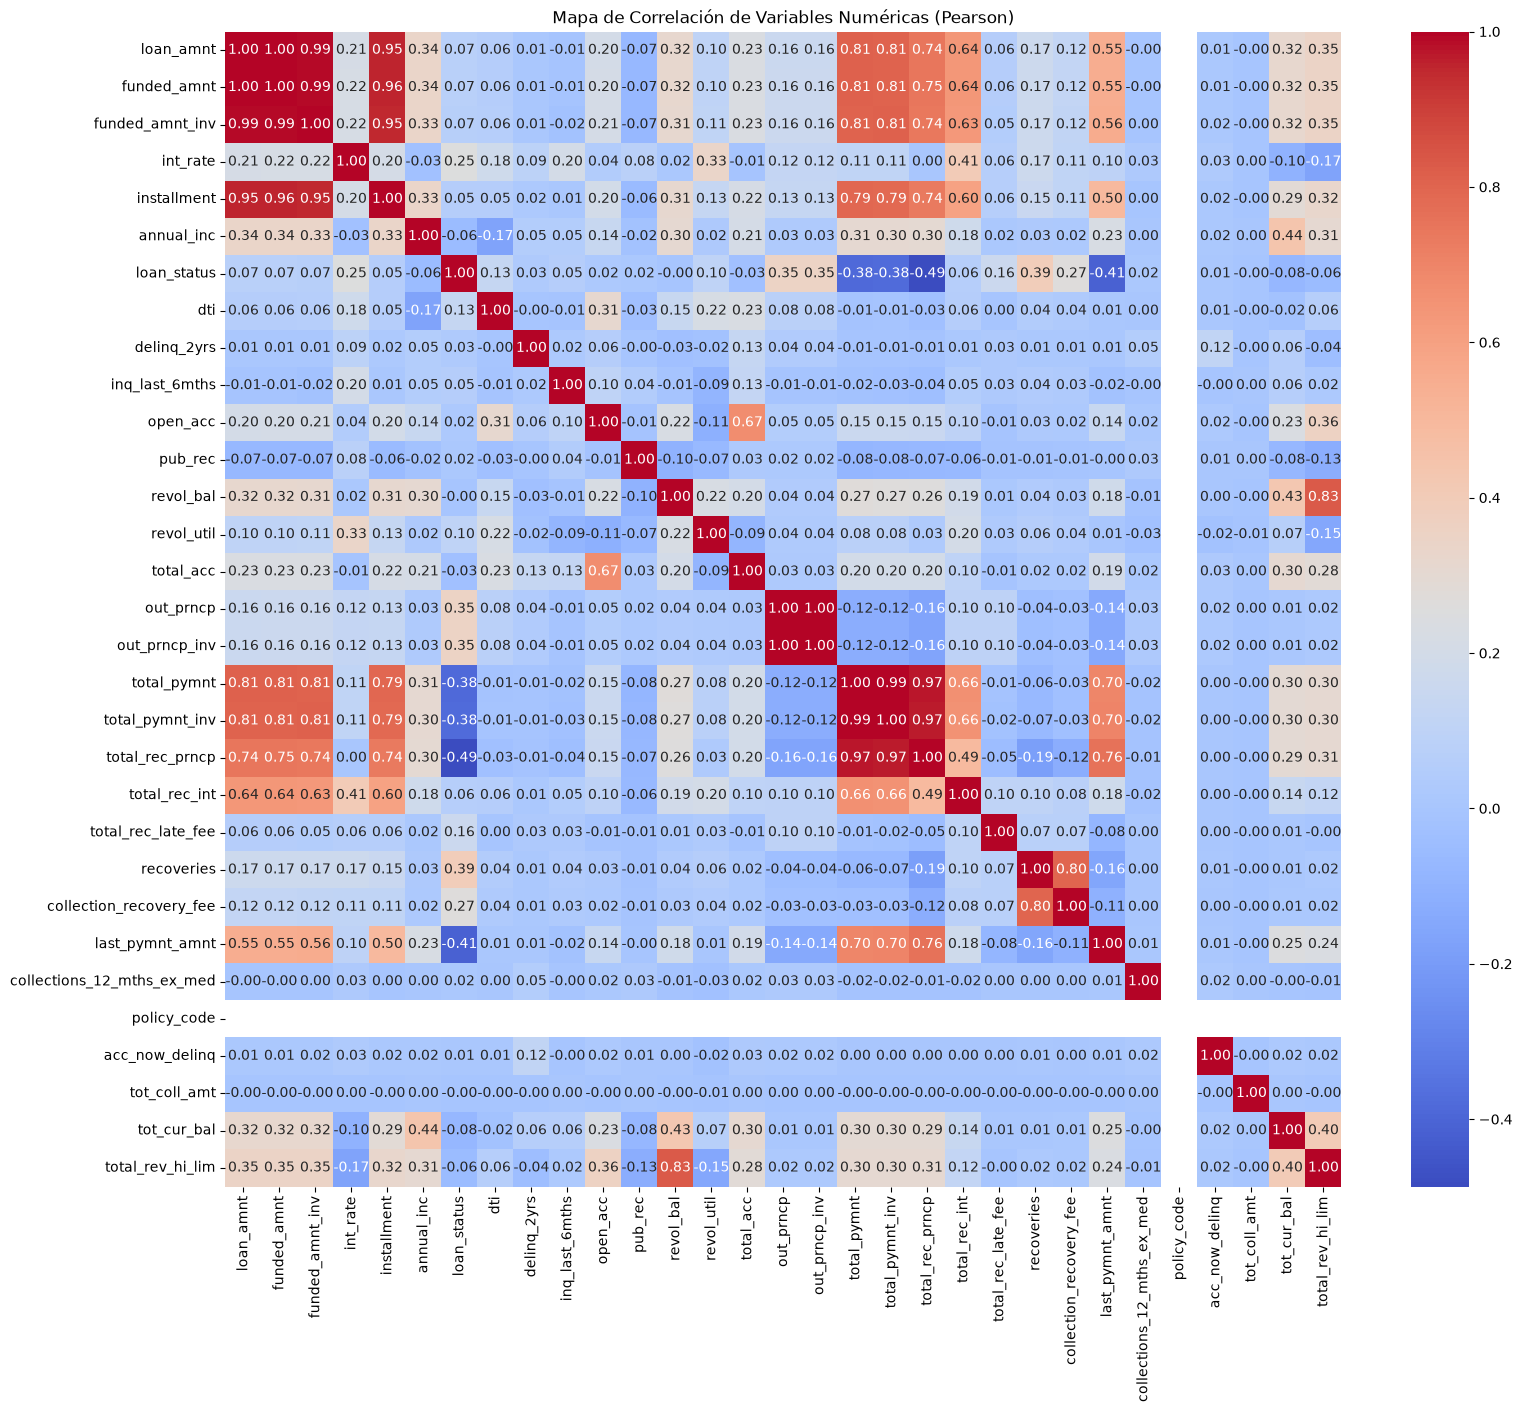

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas de df_cleaned
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
df_numerical = df_cleaned[numerical_cols]

# Calcular la matriz de correlación
correlation_matrix = df_numerical.corr()

# Crear el mapa de calor de correlación
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación de Variables Numéricas (Pearson)')
plt.show()

Se observa una alta correlación lineal entre varias variables, por lo que podemos prescindir de varias de ellas.

In [14]:
import numpy as np

# Obtener la matriz de correlación de las columnas numéricas
correlation_matrix = df_numerical.corr().abs()

# Crear un conjunto para almacenar las columnas a eliminar
columns_to_drop_corr = set()

# Iterar sobre la matriz de correlación (triangulo superior)
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) >= 0.6:  # Umbral de correlación de +-0.6
            colname = correlation_matrix.columns[i]
            # Solo agregar si la columna "j" (la que se conserva) no fue ya marcada para eliminar
            if correlation_matrix.columns[j] not in columns_to_drop_corr:
                columns_to_drop_corr.add(colname)

# Eliminar las columnas identificadas de df_cleaned, ignorando si alguna ya no existe
df_cleaned.drop(columns=list(columns_to_drop_corr), inplace=True, errors='ignore')

print(f"Columnas eliminadas debido a alta correlación: {list(columns_to_drop_corr)}")
print(f"Nuevo tamaño del DataFrame: {df_cleaned.shape}")

Columnas eliminadas debido a alta correlación: ['total_acc', 'total_rev_hi_lim', 'funded_amnt', 'installment', 'funded_amnt_inv', 'total_pymnt_inv', 'collection_recovery_fee', 'total_pymnt', 'out_prncp_inv', 'total_rec_int', 'total_rec_prncp']
Nuevo tamaño del DataFrame: (268530, 36)


Observemos la nueva matriz de correlación

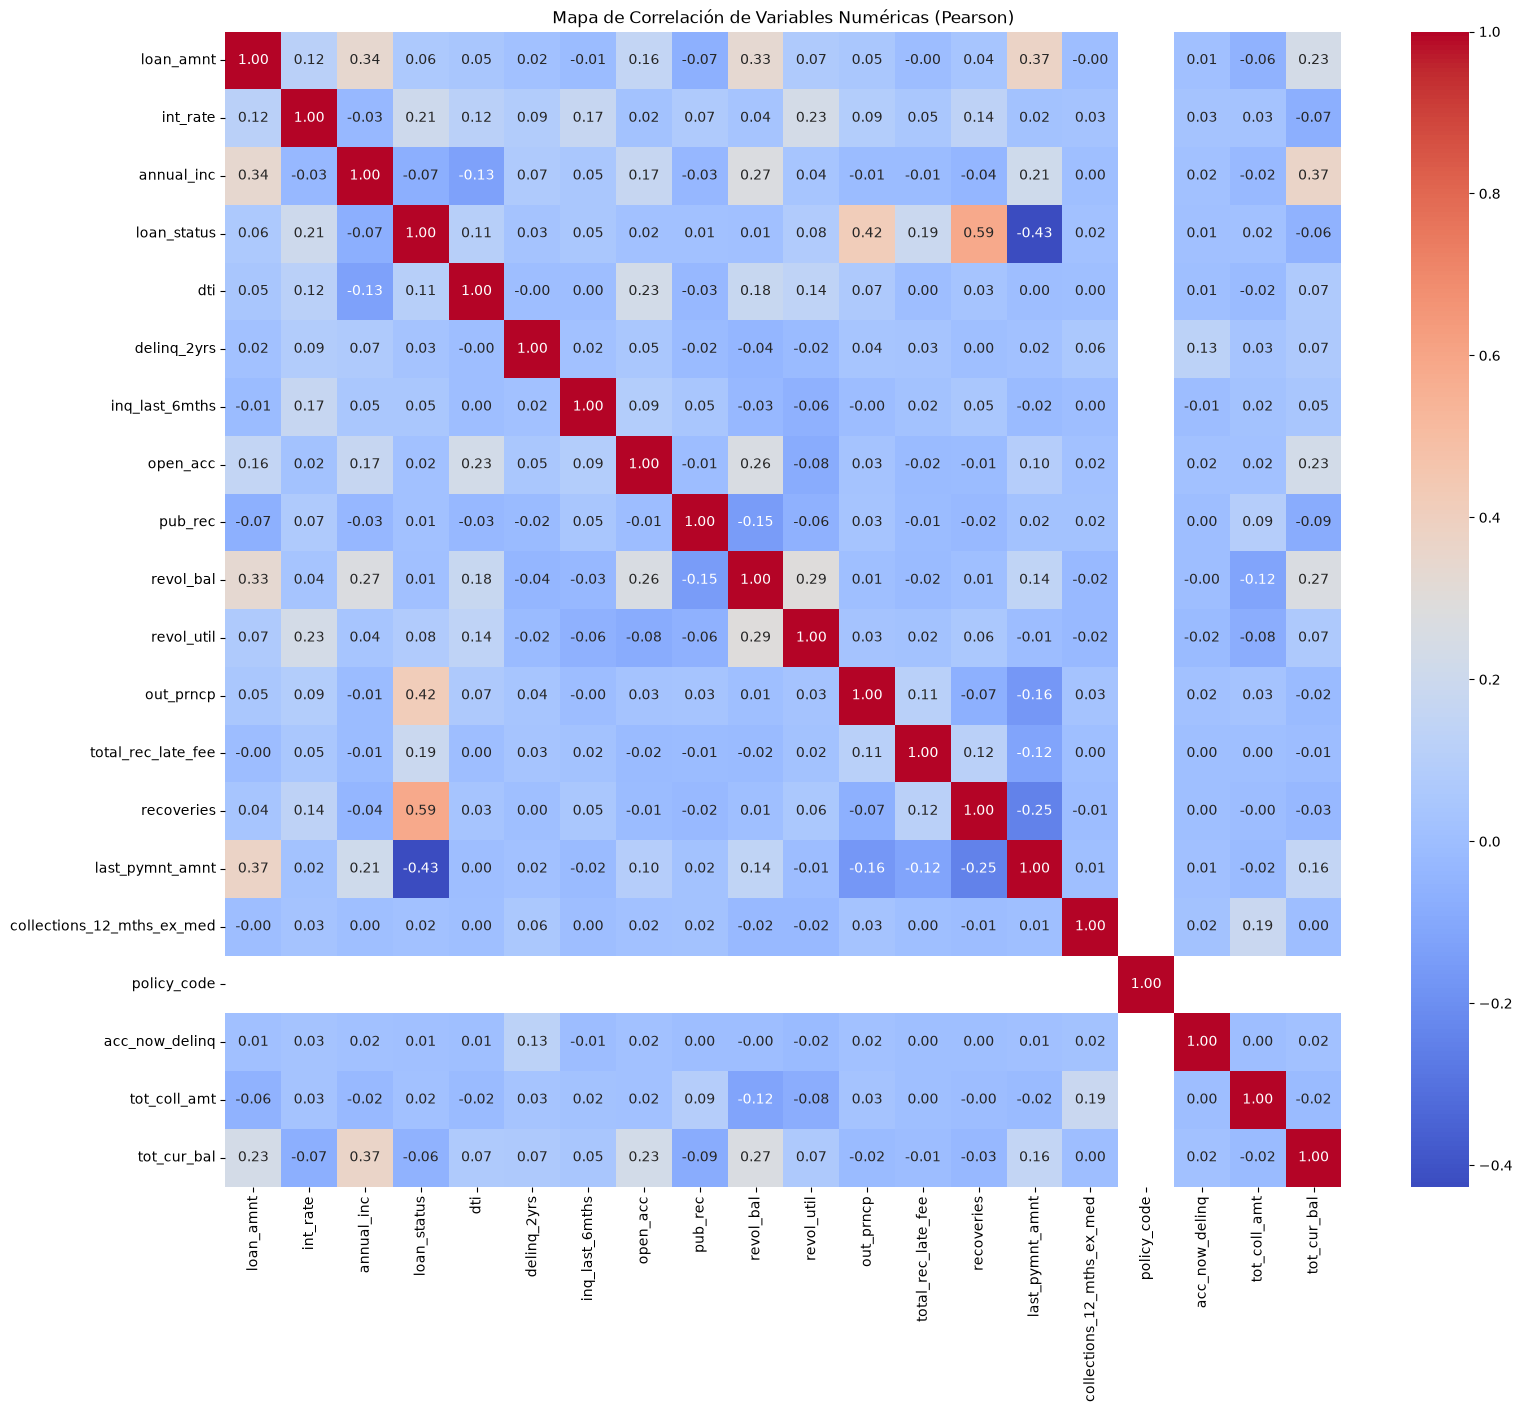

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas de df_cleaned
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
df_numerical = df_cleaned[numerical_cols]

# Calcular la matriz de correlación
correlation_matrix = df_numerical.corr(method="kendall")

# Crear el mapa de calor de correlación
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación de Variables Numéricas (Pearson)')
plt.show()

También podemos observar correlacion de Spearman

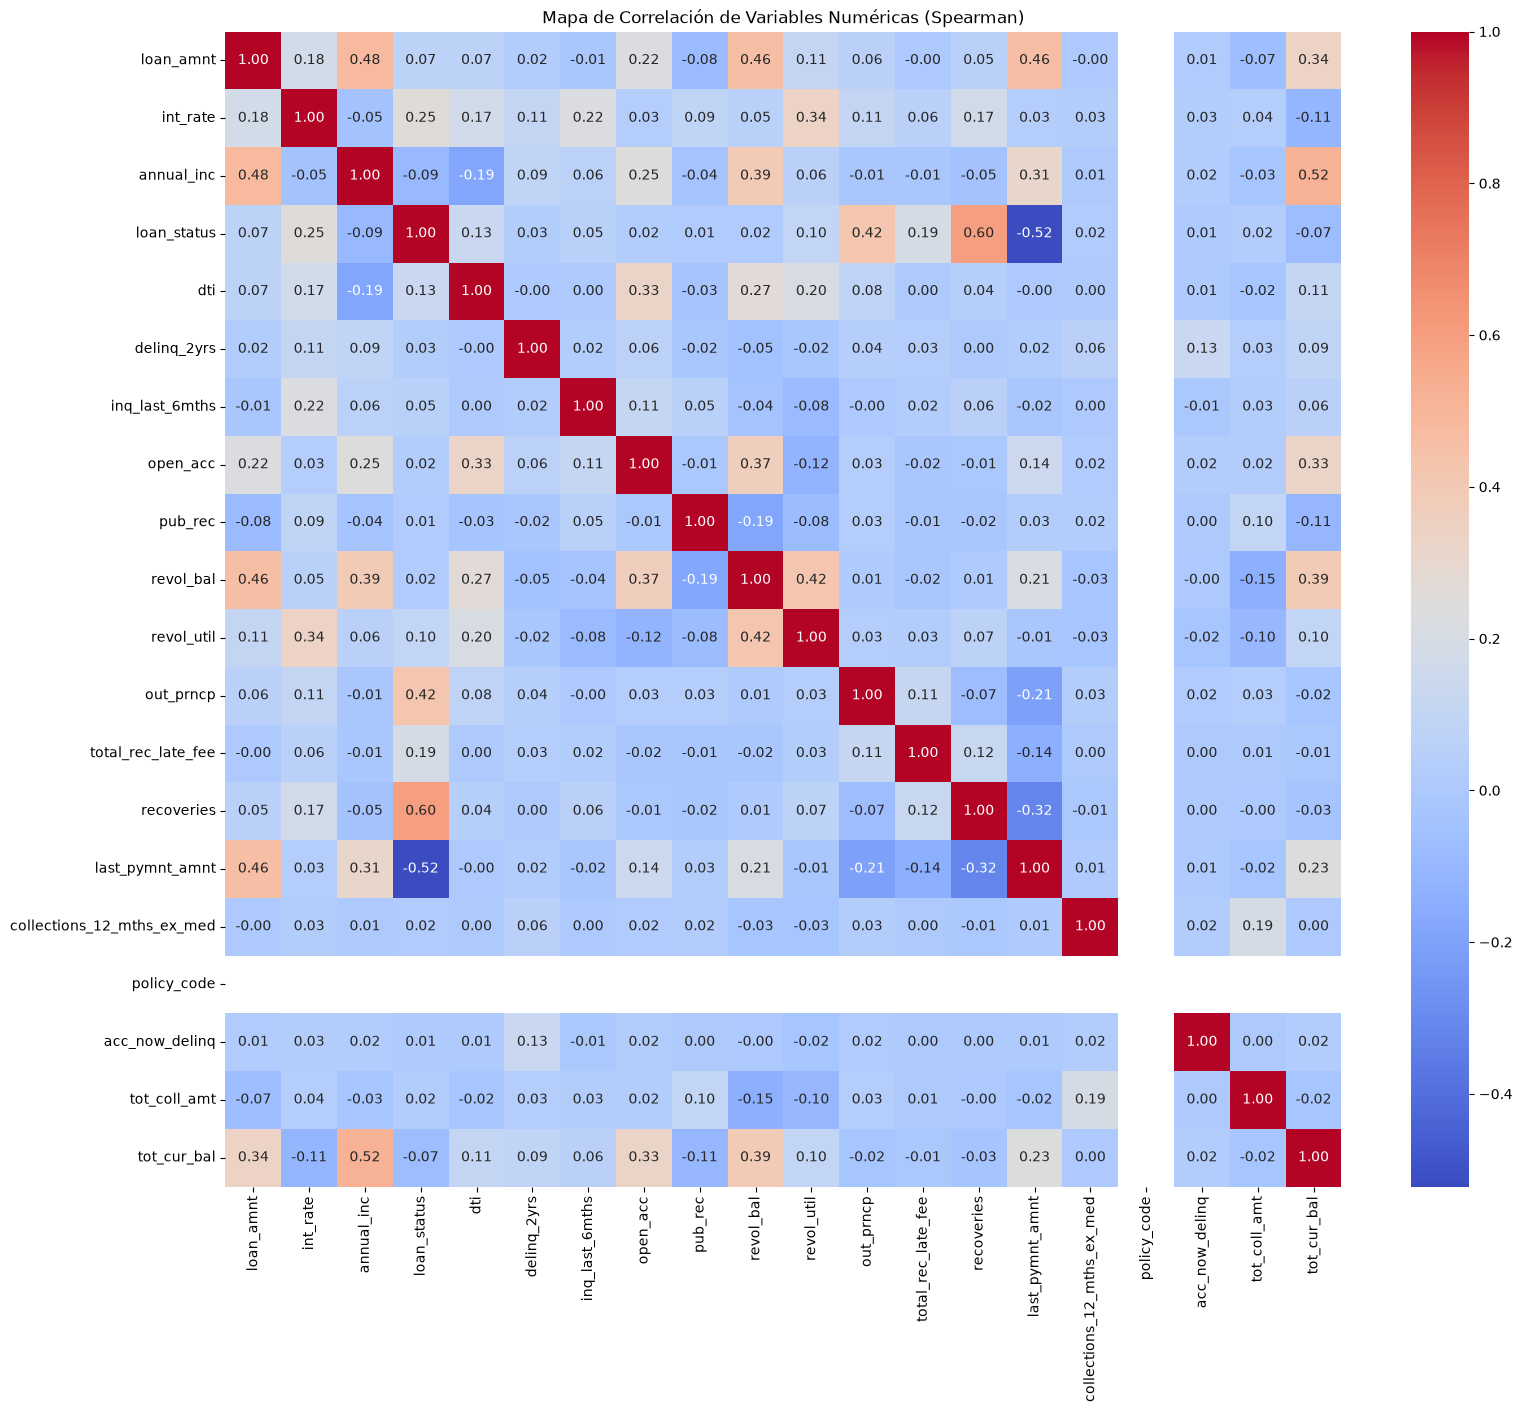

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas de df_cleaned
numerical_cols = df_cleaned.select_dtypes(include=['number']).columns
df_numerical = df_cleaned[numerical_cols]

# Calcular la matriz de correlación
correlation_matrix = df_numerical.corr(method="spearman")

# Crear el mapa de calor de correlación
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación de Variables Numéricas (Spearman)')
plt.show()

Un primer vistazo a los mapas de correlación nos permiten decidir que hay ciertas variables que pueden ser explicativas para loan_status, como son:

- last_pymnt_amnt (-0.52)
- recoveries (0.60)
- total_rec_late_fee (0.19)
- out_prncp (0.42)
- int_rate (0.25)

Observemos también variables con varianza cercana a cero, las cuales no aportan mucho al modelo y podremos descartar

In [17]:
from sklearn.feature_selection import VarianceThreshold

# Seleccionamos solo columnas numéricas para el cálculo de varianza
numerical_df = df_cleaned.select_dtypes(include=['number'])

# Definimos el selector (umbral de 0.01 para detectar casi constantes)
selector = VarianceThreshold(threshold=0.01)
selector.fit(numerical_df)

# Identificar columnas a eliminar
low_variance_cols = [col for col in numerical_df.columns if col not in numerical_df.columns[selector.get_support()]]

print(f"Variables con varianza cercana a cero identificadas: {low_variance_cols}")

# Eliminar del dataframe principal
df_cleaned.drop(columns=low_variance_cols, inplace=True)

print(f"Nuevo tamaño del DataFrame: {df_cleaned.shape}")

Variables con varianza cercana a cero identificadas: ['collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq']
Nuevo tamaño del DataFrame: (268530, 33)


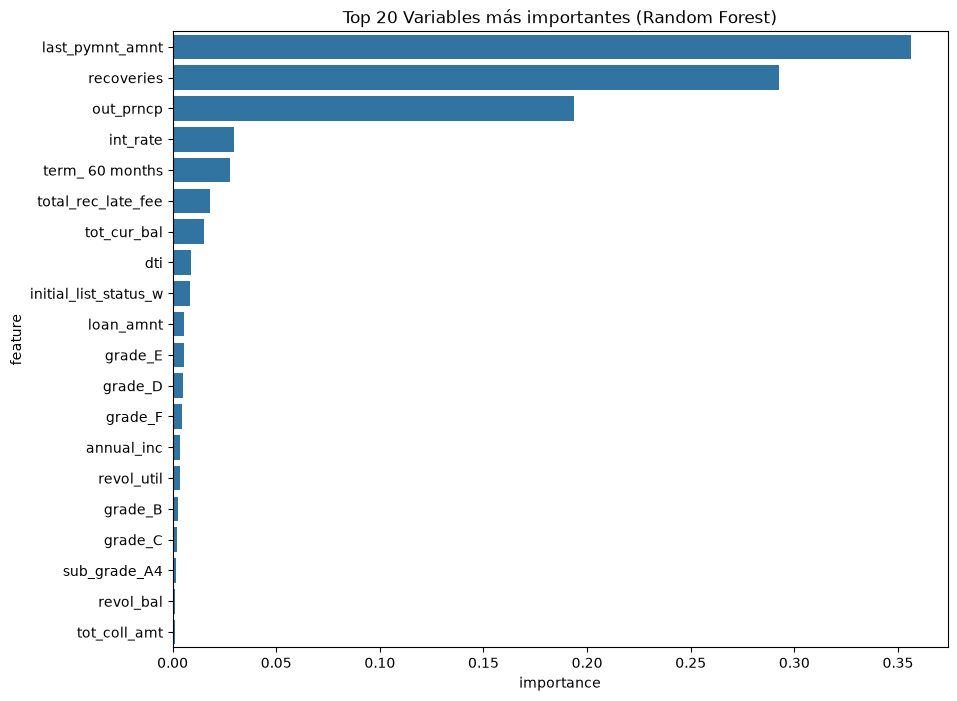

Top 10 Importancias:
                  feature  importance
13        last_pymnt_amnt    0.356140
12             recoveries    0.292410
10              out_prncp    0.193586
1                int_rate    0.029527
16        term_ 60 months    0.027584
11     total_rec_late_fee    0.017887
15            tot_cur_bal    0.015299
3                     dti    0.009023
88  initial_list_status_w    0.008162
0               loan_amnt    0.005557


In [18]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparación de datos
# Eliminamos columnas de alta cardinalidad o fechas que no son directamente útiles para RF sin procesar
X = df_cleaned.drop(columns=['loan_status'])
y = df_cleaned['loan_status']

# Identificamos columnas por tipo y cardinalidad
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(exclude=['number']).columns.tolist()

# Filtrar columnas categóricas con más de 100 valores únicos para evitar explosión de features (ej. emp_title, fechas)
low_card_cat = [col for col in cat_cols if X[col].nunique() < 50]

# Procesamiento
X_processed = X[num_cols + low_card_cat].copy()

# Imputar nulos numéricos con la mediana
for col in num_cols:
    X_processed[col] = X_processed[col].fillna(X_processed[col].median())

# Codificar variables categóricas
X_processed = pd.get_dummies(X_processed, columns=low_card_cat, drop_first=True)

# 2. Entrenar el modelo Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_processed, y)

# 3. Obtener y visualizar importancia de variables
importances = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importances.head(20))
plt.title('Top 20 Variables más importantes (Random Forest)')
plt.show()

print("Top 10 Importancias:")
print(importances.head(10))

In [19]:
# Eliminar filas con cualquier valor nulo restante
df_cleaned.dropna(inplace=True)

print(f"Tamaño del DataFrame después de eliminar nulos: {df_cleaned.shape}")
display(df_cleaned.head())

Tamaño del DataFrame después de eliminar nulos: (190394, 33)


,loan_amnt,term,int_rate,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,...,initial_list_status,out_prncp,total_rec_late_fee,recoveries,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,application_type,tot_coll_amt,tot_cur_bal
42538,12000.0,36 months,13.53,B,B5,On road manager,10+ years,RENT,40000.0,Source Verified,...,w,0.00,0.0,0.0,Sep-2015,119.17,Jan-2016,INDIVIDUAL,15386.0,13605.0
42544,3000.0,36 months,12.85,B,B4,Auditor,10+ years,RENT,25000.0,Verified,...,f,0.00,0.0,0.0,Jul-2014,2677.23,Jan-2016,INDIVIDUAL,154.0,19530.0
42546,28000.0,36 months,7.62,A,A3,Area Sales Manager,5 years,MORTGAGE,325000.0,Source Verified,...,w,0.00,0.0,0.0,Aug-2014,23915.86,Aug-2014,INDIVIDUAL,0.0,799592.0
42549,24000.0,36 months,13.53,B,B5,driver,10+ years,MORTGAGE,100000.0,Verified,...,w,0.00,0.0,0.0,Dec-2015,10726.61,Dec-2015,INDIVIDUAL,539.0,199834.0
42550,8000.0,36 months,10.99,B,B2,PARTS MANAGER,2 years,MORTGAGE,33000.0,Not Verified,...,f,4145.19,15.0,0.0,Oct-2015,276.88,Jan-2016,INDIVIDUAL,0.0,15949.0


In [20]:
df_cleaned.to_csv("../data/credit_risk_preprocessed.csv")